In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [4]:
df=pd.read_excel("../data/Glass_AMR_dataset.xlsx")

In [5]:
df.head()

,Year,Specimen,PathogenName,AntibioticName,Iso3,CountryTerritoryArea,WHORegionName,InterpretableAST,Resistant,ResistancePercentage
0,2017,BLOOD,Escherichia coli,Ciprofloxacin,ARE,United Arab Emirates,Eastern Mediterranean Region,628,304,48.407643
1,2017,BLOOD,Escherichia coli,Levofloxacin,ARE,United Arab Emirates,Eastern Mediterranean Region,31,9,29.032258
2,2017,URINE,Escherichia coli,Ciprofloxacin,ARE,United Arab Emirates,Eastern Mediterranean Region,9554,3189,33.378690
3,2017,URINE,Escherichia coli,Levofloxacin,ARE,United Arab Emirates,Eastern Mediterranean Region,790,201,25.443038
4,2017,BLOOD,Escherichia coli,Ciprofloxacin,ARG,Argentina,Region of the Americas,1803,590,32.723239


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  1213 non-null   int64  
 1   Specimen              1213 non-null   object 
 2   PathogenName          1213 non-null   object 
 3   AntibioticName        1213 non-null   object 
 4   Iso3                  1213 non-null   object 
 5   CountryTerritoryArea  1213 non-null   object 
 6   WHORegionName         1213 non-null   object 
 7   InterpretableAST      1213 non-null   int64  
 8   Resistant             1213 non-null   int64  
 9   ResistancePercentage  1213 non-null   float64
dtypes: float64(1), int64(3), object(6)
memory usage: 94.9+ KB


In [7]:
df.isnull().sum()

Year                    0
Specimen                0
PathogenName            0
AntibioticName          0
Iso3                    0
CountryTerritoryArea    0
WHORegionName           0
InterpretableAST        0
Resistant               0
ResistancePercentage    0
dtype: int64

In [8]:
df["PathogenName"].value_counts()

PathogenName
Escherichia coli    1213
Name: count, dtype: int64

In [9]:
df["AntibioticName"].value_counts()

AntibioticName
Ciprofloxacin    761
Levofloxacin     452
Name: count, dtype: int64

In [10]:
df["ResistancePercentage"].describe()

count    1213.000000
mean       42.029530
std        20.004798
min         0.000000
25%        27.607362
50%        41.264706
75%        56.923077
max       100.000000
Name: ResistancePercentage, dtype: float64

<Axes: xlabel='Year'>

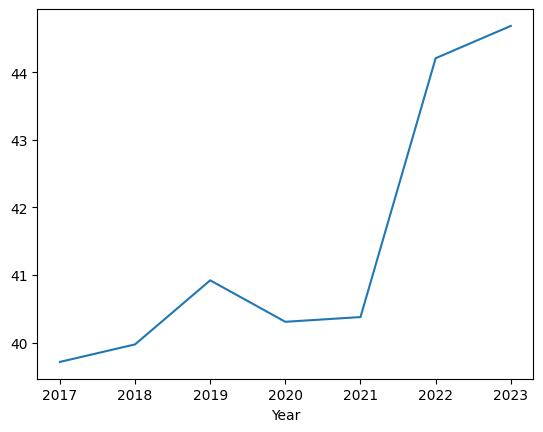

In [ ]:

df.groupby("Year")["ResistancePercentage"].mean().plot()

In [13]:
df["CountryTerritoryArea"].value_counts()

CountryTerritoryArea
United Arab Emirates    28
Japan                   28
Saudi Arabia            28
Philippines             28
Thailand                28
                        ..
Afghanistan              2
Djibouti                 1
Burundi                  1
Chad                     1
Nigeria                  1
Name: count, Length: 112, dtype: int64

In [14]:
features = [
    "Year",
    "CountryTerritoryArea",
    "Specimen",
    "AntibioticName",
    "InterpretableAST"
]

target = "ResistancePercentage"

X = df[features]
y = df[target]

In [15]:
X = pd.get_dummies(X)

In [16]:
X

,Year,InterpretableAST,CountryTerritoryArea_Afghanistan,CountryTerritoryArea_Algeria,CountryTerritoryArea_Argentina,CountryTerritoryArea_Australia,CountryTerritoryArea_Austria,CountryTerritoryArea_Bahrain,CountryTerritoryArea_Bangladesh,CountryTerritoryArea_Belgium,...,CountryTerritoryArea_United Republic of Tanzania,CountryTerritoryArea_Yemen,CountryTerritoryArea_Zambia,"CountryTerritoryArea_occupied Palestinian territory, including east Jerusalem",Specimen_BLOOD,Specimen_Bloodstream,Specimen_URINE,Specimen_Urinary tract,AntibioticName_Ciprofloxacin,AntibioticName_Levofloxacin
0,2017,628,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,2017,31,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,9554,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,2017,790,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,2017,1803,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,2023,24,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1209,2023,89,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1210,2023,52,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
1211,2023,4531,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [18]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [21]:

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
predictions = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2:", r2)

MAE: 6.819277278373724
R2: 0.7437621509373078


In [28]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


In [29]:

feature_importance.head(10)

InterpretableAST                  0.275596
CountryTerritoryArea_Pakistan     0.064839
CountryTerritoryArea_India        0.057682
Year                              0.034866
CountryTerritoryArea_Myanmar      0.031579
Specimen_Urinary tract            0.027912
CountryTerritoryArea_Qatar        0.021764
CountryTerritoryArea_Norway       0.021721
CountryTerritoryArea_Indonesia    0.021352
Specimen_Bloodstream              0.019125
dtype: float64

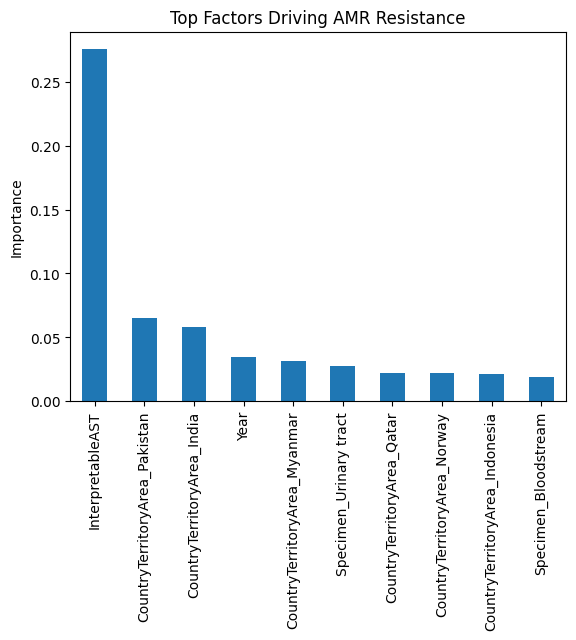

In [30]:
feature_importance.head(10).plot(kind="bar")

plt.title("Top Factors Driving AMR Resistance")
plt.ylabel("Importance")
plt.show()

In [31]:
df = df.sort_values(["CountryTerritoryArea","Year"])

df["PrevResistance"] = df.groupby(
    "CountryTerritoryArea"
)["ResistancePercentage"].shift(1)

In [32]:
df = df.dropna(subset=["PrevResistance"])

In [ ]:
features = [
    "Year",
    "CountryTerritoryArea",
    "Specimen",
    "AntibioticName",
    "InterpretableAST",
    "PrevResistance"
]

target = "ResistancePercentage"